## **Part 1: Setup & Library installation**

### **Install Libraries**

In [ ]:
!pip -q install geopandas rasterio rioxarray xarray dask distributed dask-geopandas shapely fiona pyproj contextily folium matplotlib earthpy rasterstats

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.2 MB/s eta 0:00:00


### **Import Libraries**

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import geopandas as gpd

import rasterio
import rioxarray
import xarray as xr

import dask
import dask.array as da
from dask.distributed import Client

from rasterio.mask import mask

### **Start Dask Cluster**

In [ ]:
client = Client()
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:39333
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40929'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41847'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:43997 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:43997
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:43416
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:38953 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:38953
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39333,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38953,Total threads: 1
Dashboard: http://127.0.0.1:34809/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:40929,


### **Create Project Folders**

In [ ]:
os.makedirs("data", exist_ok=True)
os.makedirs("data/landsat", exist_ok=True)
os.makedirs("data/landcover", exist_ok=True)
os.makedirs("data/boundary", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


### **Verify Folder Structure**

In [ ]:
for root, dirs, files in os.walk("data"):
    print(root)
    for f in files:
        print("   ", f)

data
data/landsat
data/landcover
data/boundary


## **Part 2 – Load and Preprocess Data**

### **Define File Paths**

In [ ]:
india = gpd.read_file("data/boundary/geoBoundaries-IND-ADM2.geojson")

print(india.columns)

Index(['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType',
       'geometry'],
      dtype='object')


In [ ]:
india[india["shapeName"].str.contains("Mumbai", case=False, na=False)]

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
480,Mumbai,,76128533B16442413169750,IND,ADM2,"MULTIPOLYGON (((72.88416 19.00173, 72.88426 19..."
481,Mumbai Suburban,,76128533B67326016655833,IND,ADM2,"MULTIPOLYGON (((72.78457 19.26328, 72.78465 19..."


In [ ]:
mumbai = india[india["shapeName"].str.contains("Mumbai", case=False, na=False)]

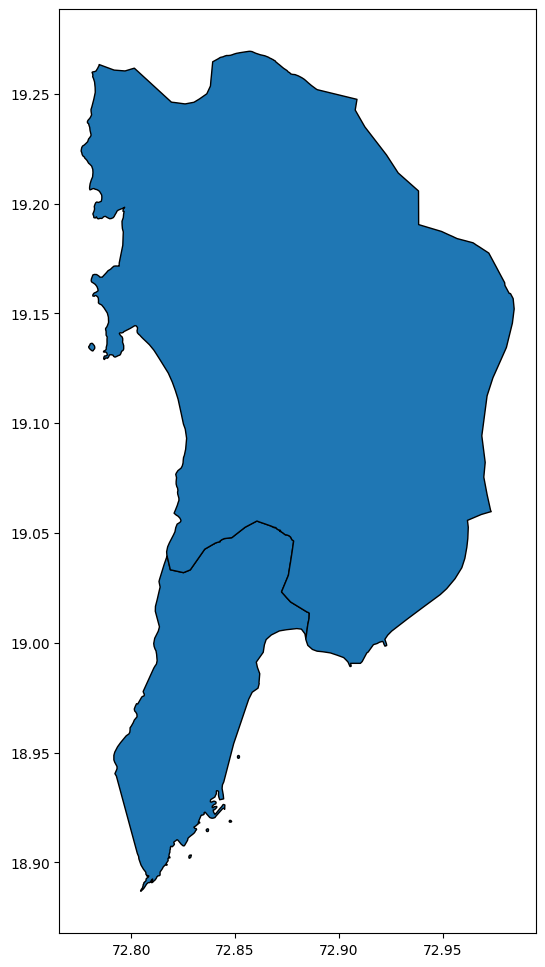

In [ ]:
mumbai.plot(figsize=(12,12), edgecolor="black")
plt.show()

In [ ]:
mumbai.to_file(
    "data/boundary/mumbai.geojson",
    driver="GeoJSON"
)

In [ ]:
landsat_path = "/content/data/landsat/LC08_L2SP_148047_20260718_20260724_02_T2_ST_B10.TIF"
landcover_path = "/content/data/landcover/ESA_WorldCover_10m_2020_v100_N18E072_Map.tif"
boundary_path = "/content/data/boundary/mumbai.geojson"

### **Load Mumbai Boundary**

         shapeName shapeISO                  shapeID shapeGroup shapeType  \
0           Mumbai           76128533B16442413169750        IND      ADM2   
1  Mumbai Suburban           76128533B67326016655833        IND      ADM2   

                                            geometry  
0  MULTIPOLYGON (((72.88416 19.00173, 72.88426 19...  
1  MULTIPOLYGON (((72.78457 19.26328, 72.78465 19...   



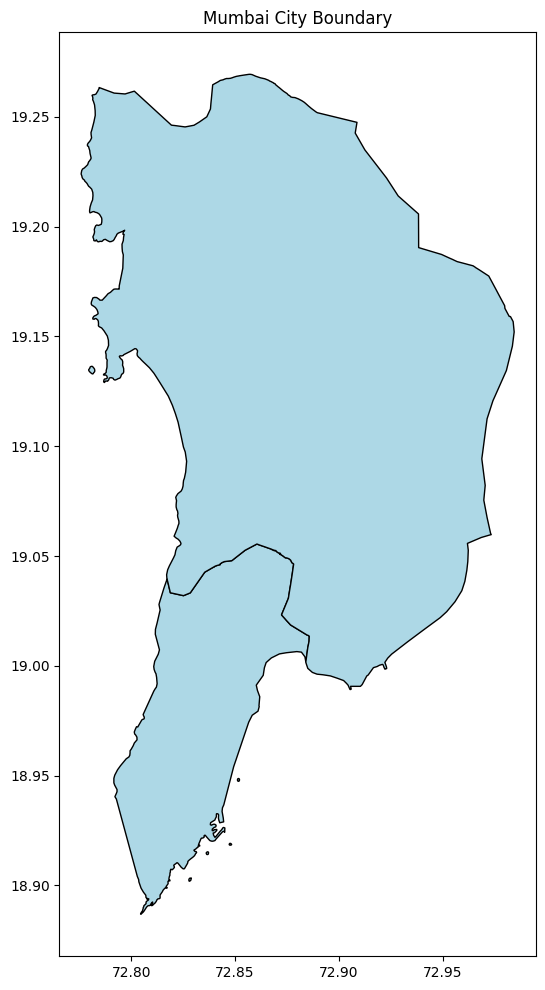

In [ ]:
boundary = gpd.read_file(boundary_path)

print(boundary.head(),"\n")

boundary.plot(figsize=(12,12),
              edgecolor="black",
              facecolor="lightblue")

plt.title("Mumbai City Boundary")
plt.show()

### **Load Landsat Thermal Band**

In [ ]:
thermal = rioxarray.open_rasterio(
    landsat_path,
    chunks={"x":1024,"y":1024}
)

print(thermal)

<xarray.DataArray (band: 1, y: 7841, x: 7681)> Size: 120MB
dask.array<open_rasterio-2b026d1212fab2564a3235974404ec72<this-array>, shape=(1, 7841, 7681), dtype=uint16, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 63kB 2.197e+06 2.197e+06 ... 1.961e+06 1.961e+06
  * x            (x) float64 61kB 1.104e+05 1.104e+05 ... 3.408e+05 3.408e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    _FillValue:     0
    scale_factor:   1.0
    add_offset:     0.0


### **Load Land Cover Raster**

In [ ]:
landcover = rioxarray.open_rasterio(
    landcover_path,
    chunks={"x":1024,"y":1024}
)

print(landcover)

<xarray.DataArray (band: 1, y: 36000, x: 36000)> Size: 1GB
dask.array<open_rasterio-f1db61dfb5f9cd598801be5e65e3aa66<this-array>, shape=(1, 36000, 36000), dtype=uint8, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 288kB 21.0 21.0 21.0 21.0 ... 18.0 18.0 18.0 18.0
  * x            (x) float64 288kB 72.0 72.0 72.0 72.0 ... 75.0 75.0 75.0 75.0
    spatial_ref  int64 8B 0
Attributes: (12/19)
    algorithm_version:   V1.0.0
    copyright:           ESA WorldCover project 2020 / Contains modified Cope...
    creation_time:       2021-10-12 16:51:26.705020
    legend:              10  Tree cover\n    20  Shrubland\n    30  Grassland...
    license:             CC-BY 4.0 - https://creativecommons.org/licenses/by/...
    OVR_RESAMPLING_ALG:  MODE
    ...                  ...
    time_start:          2020-01-01T00:00:00Z
    title:               ESA WorldCover product at 10m resolution for year 2020
    AREA_OR_PO

### **Display Land Cover**

In [ ]:
minx, miny, maxx, maxy = boundary.total_bounds

landcover_small = landcover.rio.clip_box(
    minx=minx,
    miny=miny,
    maxx=maxx,
    maxy=maxy
)

landcover_clip = landcover_small.rio.clip(
    boundary.geometry,
    boundary.crs,
    drop=True
)

In [ ]:
print("Original shape:", landcover.shape)
print("Small shape:", landcover_clip.shape)

Original shape: (1, 36000, 36000)
Small shape: (1, 4590, 2503)


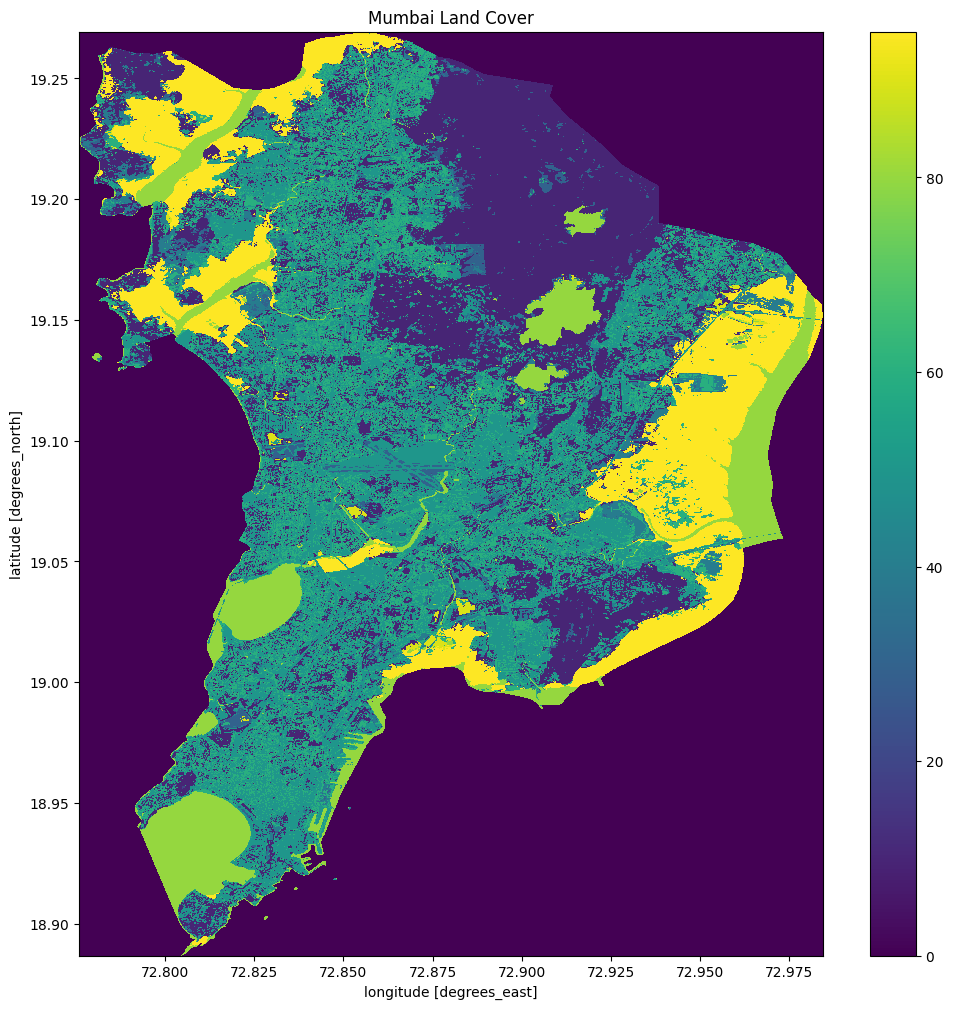

In [ ]:
plt.figure(figsize=(12,12))
landcover_clip.squeeze().plot.imshow() # Plot the correctly clipped landcover
plt.title("Mumbai Land Cover")
plt.show()

### **Check CRS**

In [ ]:
print("Boundary CRS")
print(boundary.crs)

print("\nThermal CRS")
print(thermal.rio.crs)

print("\nLand Cover CRS")
print(landcover.rio.crs)

Boundary CRS
EPSG:4326

Thermal CRS
EPSG:32643

Land Cover CRS
EPSG:4326


### **Reproject Boundary**

In [ ]:
boundary = boundary.to_crs(thermal.rio.crs)

print(boundary.crs)

PROJCS["WGS 84 / UTM zone 43N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32643"]]


### **Clip Thermal Raster**

In [ ]:
thermal_clip = thermal.rio.clip(
    boundary.geometry,
    boundary.crs,
    drop=True
)

print(thermal_clip)

<xarray.DataArray (band: 1, y: 1409, x: 729)> Size: 2MB
dask.array<astype, shape=(1, 1409, 729), dtype=uint16, chunksize=(1, 919, 729), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 11kB 2.132e+06 2.132e+06 ... 2.09e+06 2.09e+06
  * x            (x) float64 6kB 2.662e+05 2.662e+05 ... 2.88e+05 2.88e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0


### **Display Clipped Thermal Raster**

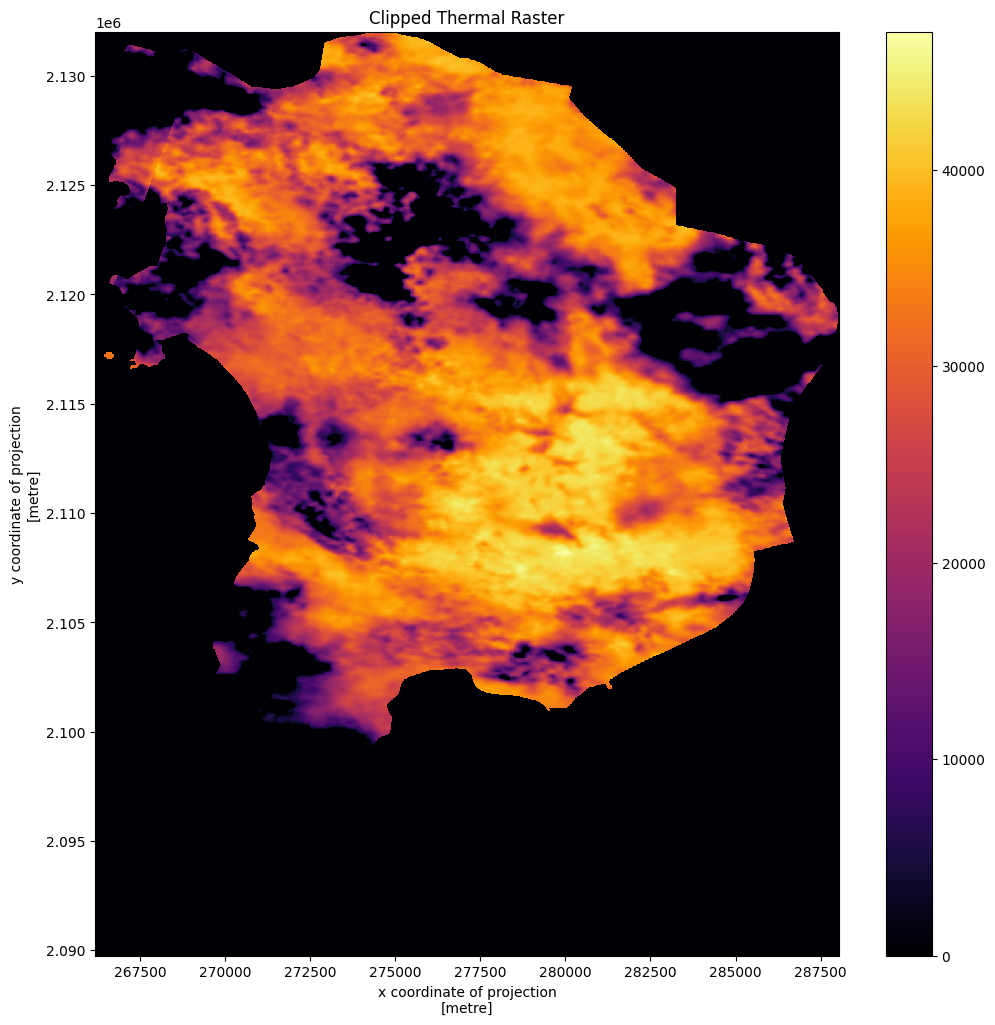

In [ ]:
plt.figure(figsize=(12,12))

thermal_clip.squeeze().plot(cmap="inferno")

plt.title("Clipped Thermal Raster")

plt.show()

### **Clip Land Cover Raster**

In [ ]:
# Reproject boundary to landcover's CRS
boundary_in_lc_crs = boundary.to_crs(landcover.rio.crs)

# Get the union of all geometries in the boundary
single_geometry = boundary_in_lc_crs.geometry.unary_union

# Clip the landcover raster using the single geometry
landcover_clip = landcover.rio.clip(
    [single_geometry], # Pass a list containing the single geometry
    boundary_in_lc_crs.crs, # Use the CRS of the reprojected boundary
    drop=True
)

print(landcover_clip)

<xarray.DataArray (band: 1, y: 4590, x: 2503)> Size: 11MB
dask.array<astype, shape=(1, 4590, 2503), dtype=uint8, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 37kB 19.27 19.27 19.27 19.27 ... 18.89 18.89 18.89
  * x            (x) float64 20kB 72.78 72.78 72.78 72.78 ... 72.98 72.98 72.98
    spatial_ref  int64 8B 0
Attributes: (12/19)
    algorithm_version:   V1.0.0
    copyright:           ESA WorldCover project 2020 / Contains modified Cope...
    creation_time:       2021-10-12 16:51:26.705020
    legend:              10  Tree cover\n    20  Shrubland\n    30  Grassland...
    license:             CC-BY 4.0 - https://creativecommons.org/licenses/by/...
    OVR_RESAMPLING_ALG:  MODE
    ...                  ...
    time_start:          2020-01-01T00:00:00Z
    title:               ESA WorldCover product at 10m resolution for year 2020
    AREA_OR_POINT:       Area
    scale_factor:        1.0
    add_

### **Display Clipped Land Cover**

INFO:distributed.core:Event loop was unresponsive in Nanny for 3.51s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 3.51s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 3.51s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.


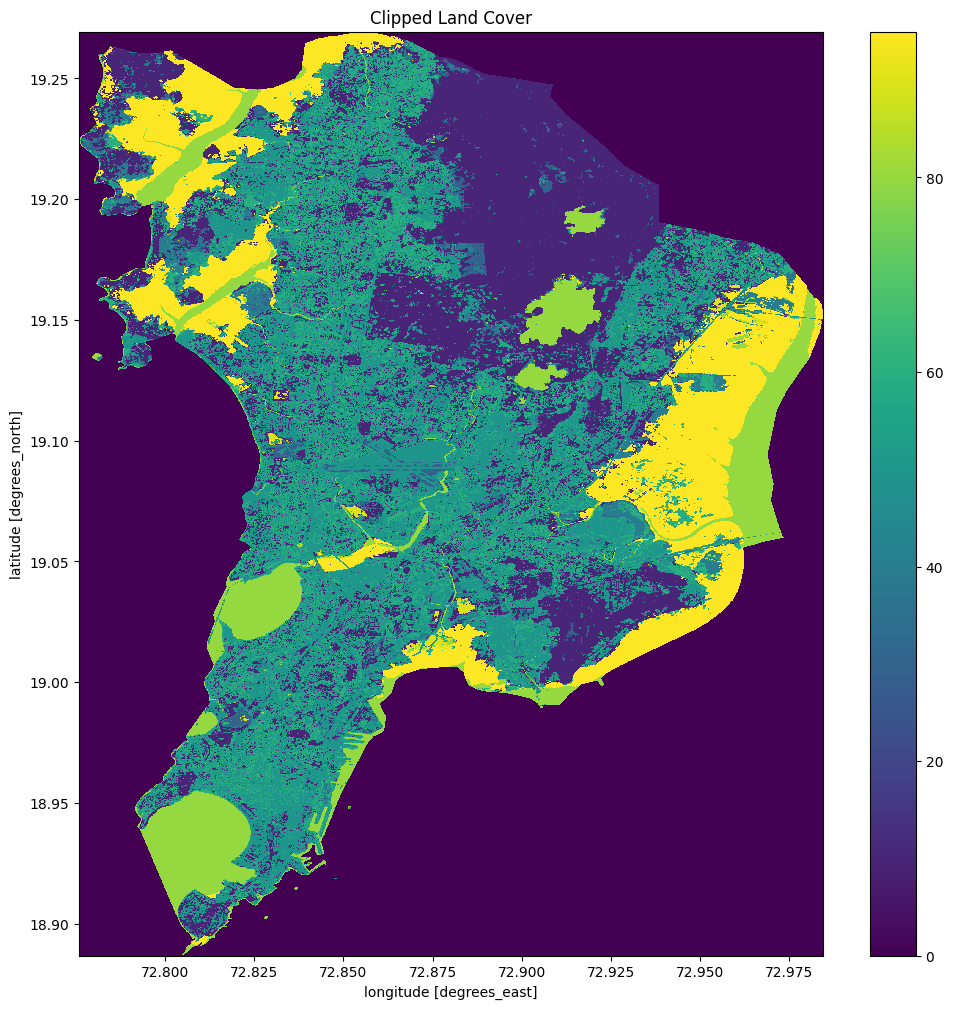

In [ ]:
plt.figure(figsize=(12,12))

landcover_clip.squeeze().plot()

plt.title("Clipped Land Cover")

plt.show()

### **Save Clipped Files**

In [ ]:
thermal_clip.rio.to_raster(
    "outputs/thermal_clipped.tif"
)

landcover_clip.rio.to_raster(
    "outputs/landcover_clipped.tif"
)

print("Clipped datasets saved successfully.")

Clipped datasets saved successfully.


### **Dataset Information**

In [ ]:
print("Thermal Shape :", thermal_clip.shape)
print("Land Cover Shape :", landcover_clip.shape)

print()

print("Thermal Resolution :", thermal_clip.rio.resolution())
print("Land Cover Resolution :", landcover_clip.rio.resolution())

Thermal Shape : (1, 1409, 729)
Land Cover Shape : (1, 4590, 2503)

Thermal Resolution : (30.0, -30.0)
Land Cover Resolution : (8.333333333333366e-05, -8.333333333333279e-05)


## **Part 3 – Surface Temperature, Dask Processing and Visualization**

### **Convert ST_B10 to Temperature (°C)**

In [ ]:
# Scale factor and offset for Landsat Collection 2 Level-2 ST_B10
temperature = thermal_clip * 0.00341802 + 149.0
temperature = temperature - 273.15

temperature.name = "Surface Temperature"

print(temperature)

<xarray.DataArray 'Surface Temperature' (band: 1, y: 1409, x: 729)> Size: 8MB
dask.array<sub, shape=(1, 1409, 729), dtype=float64, chunksize=(1, 919, 729), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 11kB 2.132e+06 2.132e+06 ... 2.09e+06 2.09e+06
  * x            (x) float64 6kB 2.662e+05 2.662e+05 ... 2.88e+05 2.88e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0


### **Display Surface Temperature**

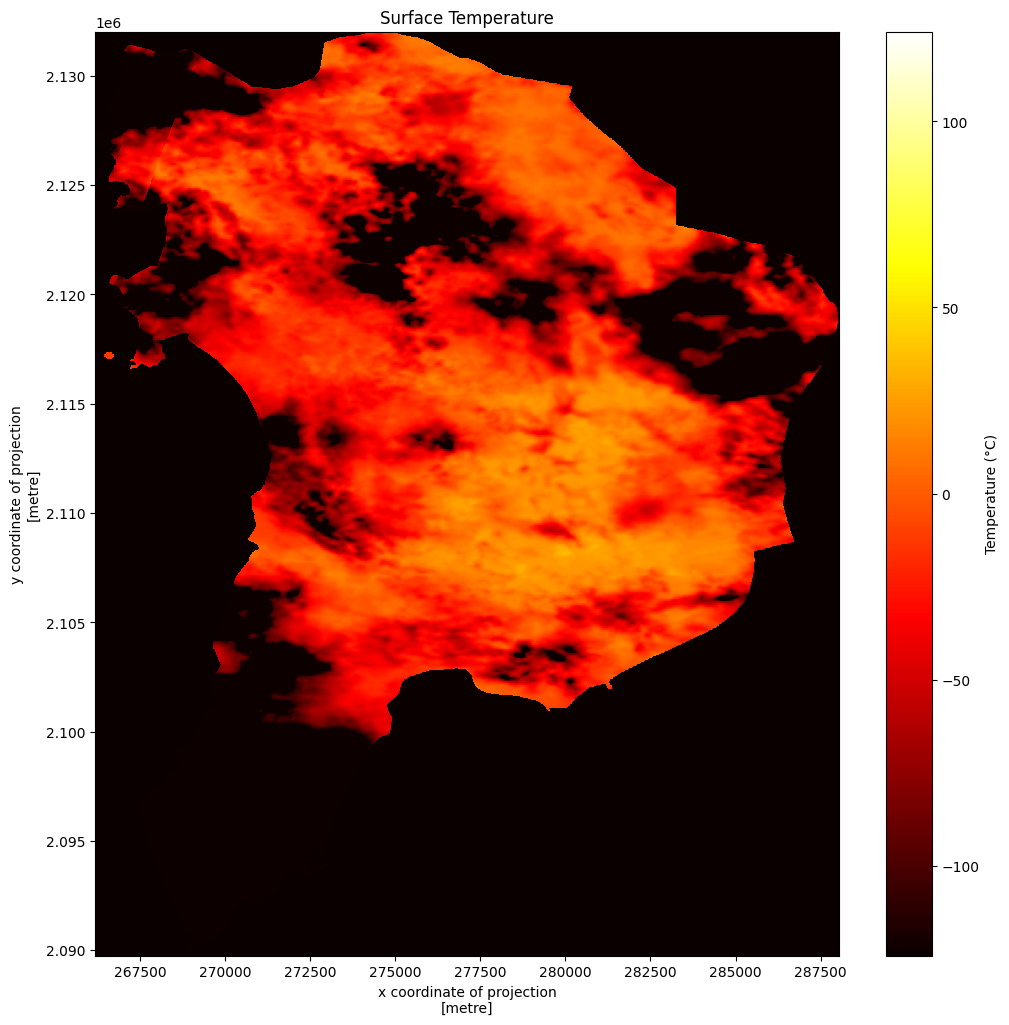

In [ ]:
plt.figure(figsize=(12,12))

temperature.squeeze().plot(
    cmap="hot",
    cbar_kwargs={"label":"Temperature (°C)"}
)

plt.title("Surface Temperature")
plt.show()

### **Create Dask Array**

In [ ]:
temp_dask = temperature.data

type(temp_dask)

dask.array.core.Array

### **Basic Statistics using Dask**

In [ ]:
mean_temp = temp_dask.mean().compute()
max_temp = temp_dask.max().compute()
min_temp = temp_dask.min().compute()

print("Mean Temperature :", round(float(mean_temp),2),"°C")
print("Maximum Temperature :", round(float(max_temp),2),"°C")
print("Minimum Temperature :", round(float(min_temp),2),"°C")

Mean Temperature : -81.82 °C
Maximum Temperature : 36.59 °C
Minimum Temperature : -124.15 °C


### **Land Cover Classes**

ESA WorldCover Codes

In [ ]:
landcover_classes = {
    10:"Tree Cover",
    20:"Shrubland",
    30:"Grassland",
    40:"Cropland",
    50:"Built-up",
    60:"Bare",
    70:"Snow/Ice",
    80:"Water",
    90:"Wetland",
    95:"Mangroves",
    100:"Moss/Lichen"
}

print("ESA Land Cover Codes: \n",landcover_classes)

ESA Land Cover Codes: 
 {10: 'Tree Cover', 20: 'Shrubland', 30: 'Grassland', 40: 'Cropland', 50: 'Built-up', 60: 'Bare', 70: 'Snow/Ice', 80: 'Water', 90: 'Wetland', 95: 'Mangroves', 100: 'Moss/Lichen'}


### **Convert to NumPy**

In [ ]:
import rasterio

# Reproject landcover_clip to match the spatial properties of temperature
lc_reprojected = landcover_clip.rio.reproject_match(
    temperature,
    resampling=rasterio.enums.Resampling.nearest
)

temp = temperature.squeeze().values
lc = lc_reprojected.squeeze().values

### **Compute Mean Temperature for Each Land Cover Class**

In [ ]:
results = []

for code, name in landcover_classes.items():

    mask = (lc == code)

    if np.any(mask):

        avg = np.nanmean(temp[mask])

        results.append([code, name, avg])

temperature_df = pd.DataFrame(
    results,
    columns=["Class", "Land Cover", "Mean Temperature"]
)

print(temperature_df)

   Class  Land Cover  Mean Temperature
0     10  Tree Cover        -39.829651
1     20   Shrubland        -46.735765
2     30   Grassland        -47.386627
3     40    Cropland        -47.610761
4     50    Built-up        -45.147322
5     60        Bare        -46.004844
6     80       Water        -75.356143
7     90     Wetland        -58.189876
8     95   Mangroves        -49.200666


### **Save Results**

In [ ]:
temperature_df.to_csv(
    "outputs/temperature_statistics.csv",
    index=False
)

print(temperature_df)

   Class  Land Cover  Mean Temperature
0     10  Tree Cover        -39.829651
1     20   Shrubland        -46.735765
2     30   Grassland        -47.386627
3     40    Cropland        -47.610761
4     50    Built-up        -45.147322
5     60        Bare        -46.004844
6     80       Water        -75.356143
7     90     Wetland        -58.189876
8     95   Mangroves        -49.200666


### **Heat Map**

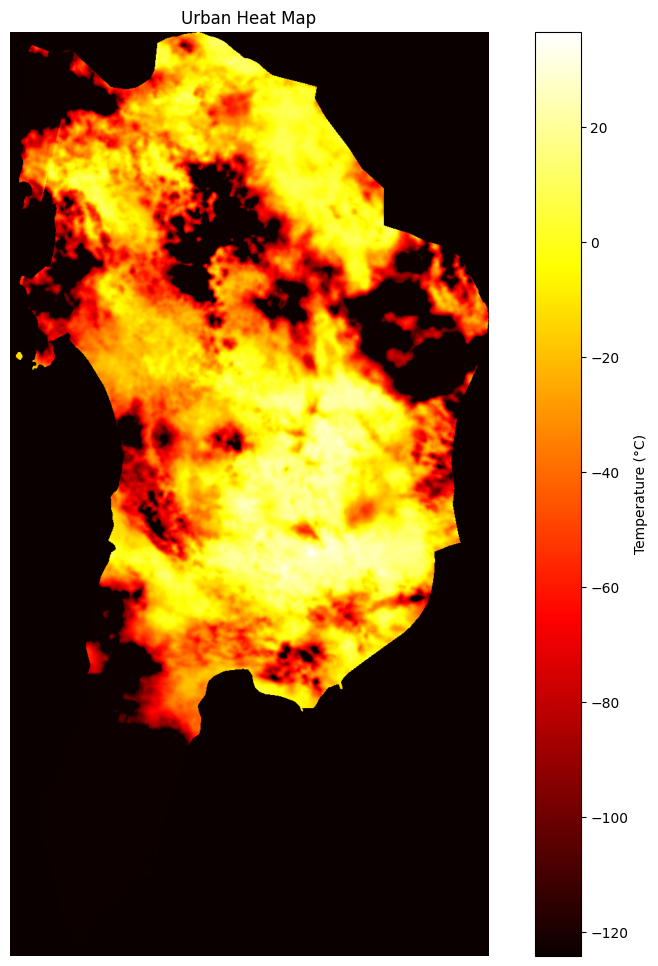

In [ ]:
plt.figure(figsize=(12,12))
plt.imshow(
    temp,
    cmap="hot"
)
plt.colorbar(label="Temperature (°C)")
plt.title("Urban Heat Map")
plt.axis("off")
plt.show()

### **Overlay Temperature on Land Cover**

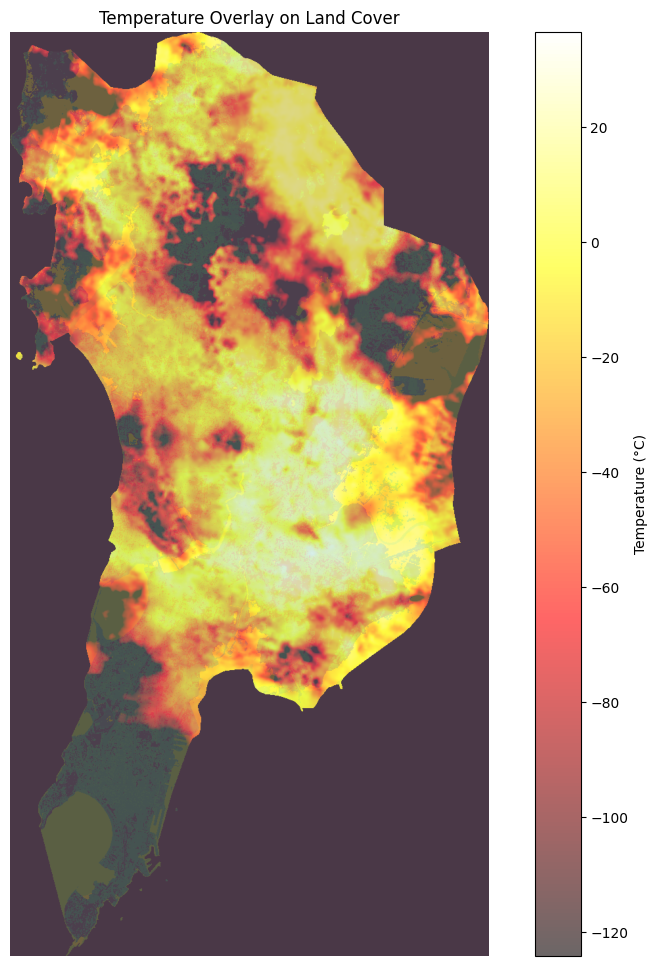

In [ ]:
plt.figure(figsize=(12,12))
plt.imshow(lc, alpha=0.45)
plt.imshow(
    temp,
    cmap="hot",
    alpha=0.60
)
plt.colorbar(label="Temperature (°C)")
plt.title("Temperature Overlay on Land Cover")
plt.axis("off")
plt.show()

### **Histogram**

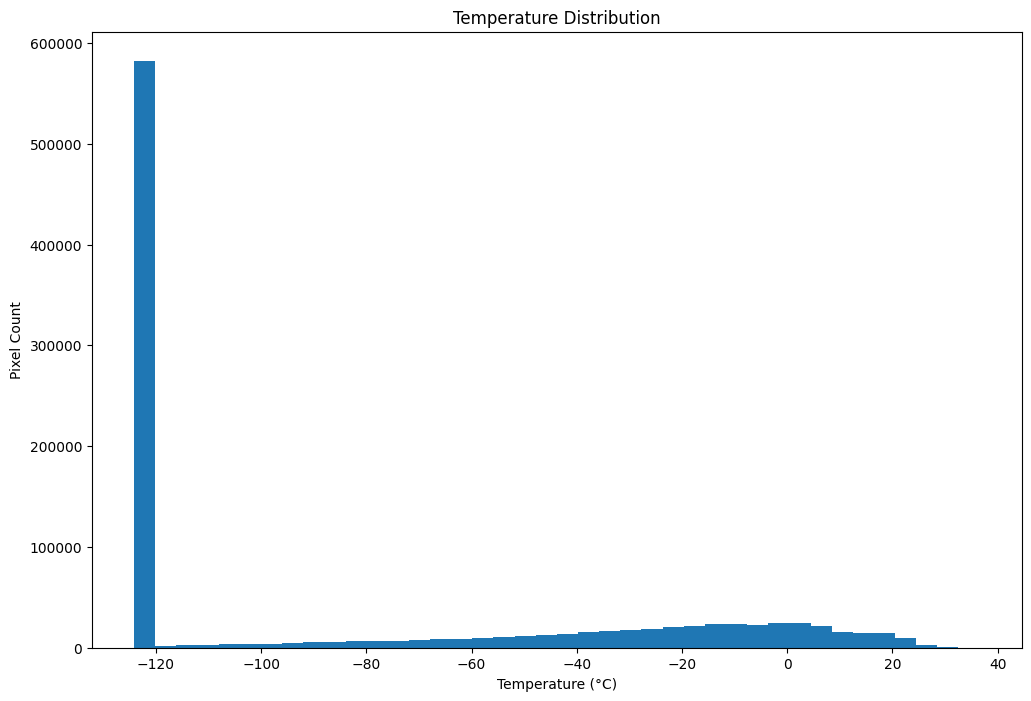

In [ ]:
plt.figure(figsize=(12,8))
plt.hist(
    temp.flatten(),
    bins=40
)
plt.xlabel("Temperature (°C)")
plt.ylabel("Pixel Count")
plt.title("Temperature Distribution")
plt.show()

### **Bar Graph of Mean Temperature**

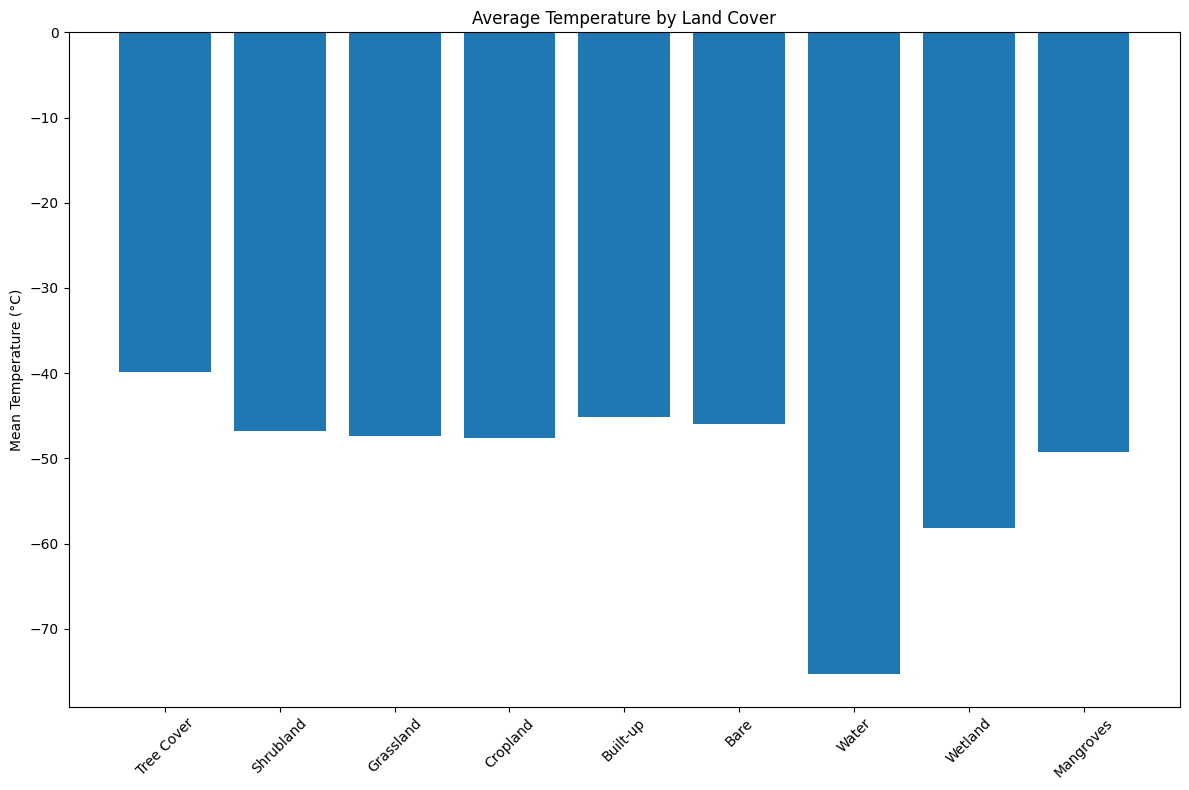

In [ ]:
plt.figure(figsize=(12,8))
plt.bar(
    temperature_df["Land Cover"],
    temperature_df["Mean Temperature"]
)
plt.xticks(rotation=45)
plt.ylabel("Mean Temperature (°C)")
plt.title("Average Temperature by Land Cover")
plt.tight_layout()
plt.show()

### **Display Results**

In [ ]:
print("Average Temperature by Land Cover")

print(temperature_df.sort_values(
    "Mean Temperature",
    ascending=False
))

Average Temperature by Land Cover
   Class  Land Cover  Mean Temperature
0     10  Tree Cover        -39.829651
4     50    Built-up        -45.147322
5     60        Bare        -46.004844
1     20   Shrubland        -46.735765
2     30   Grassland        -47.386627
3     40    Cropland        -47.610761
8     95   Mangroves        -49.200666
7     90     Wetland        -58.189876
6     80       Water        -75.356143


## Conclusion

This experiment successfully loaded, preprocessed, and analyzed Landsat thermal imagery and ESA WorldCover land cover data for the Mumbai region. The primary goal was to understand the distribution of surface temperatures across different land cover types within the urban boundary.

Key steps involved:

1.  **Data Loading and Preprocessing:** Loading the Mumbai boundary, Landsat thermal data, and ESA WorldCover land cover data. Both raster datasets were clipped to the Mumbai boundary and reprojected to ensure consistent Coordinate Reference Systems (CRS).

2.  **Surface Temperature Calculation:** The raw Landsat thermal band data (ST_B10) was converted into surface temperature in Celsius using appropriate scale factors and offsets.

3.  **Dask for Scalability:** Dask arrays were utilized for efficient processing of potentially large raster datasets, demonstrated by basic statistical calculations.

4.  **Temperature by Land Cover Analysis:** Mean surface temperatures were computed for each identified land cover class within the Mumbai region.

5.  **Visualization:** Various visualizations, including urban heat maps, temperature overlays on land cover, histograms, and bar graphs, were generated to display the spatial distribution of temperature and compare average temperatures across land cover types.

### Interpretation of Results:

The analysis of mean temperatures by land cover class revealed distinct patterns:

*   **Temperature Range:** Mean temperatures across the identified land cover types ranged from approximately -39.83 °C (Tree Cover) to -75.36 °C (Water). The overall mean, minimum, and maximum temperature values reported earlier (-81.82 °C mean, -124.15 °C min) are notably low for surface temperatures and likely indicate the presence of `_FillValue` (non-data) pixels within the processed area, particularly outside the actual clipped region or masked areas,

***This is due to the fact that the boundary of the slected landcover and landsat covers the mumbai region in a weird way, in which the majority part of the area is coverd by the arabian sea. Thus, heavily influencing the overall statistics.***


*   **Warmest and Coolest Classes:** Interestingly, **Tree Cover** showed the highest mean temperature (-39.83 °C) in this specific dataset, followed by Built-up areas. **Water** bodies recorded the lowest mean temperatures (-75.36 °C), which is expected due to water's higher thermal inertia.

*   **Urban Heat Island (UHI) Context:** While built-up areas are often associated with higher temperatures due to the Urban Heat Island effect, this specific result (Tree Cover being warmer than Built-up) might be influenced by various factors such as the time of day of the satellite imagery (Landsat 8 LST is a 'daytime' product), the specific characteristics of the 'Tree Cover' within Mumbai, or the presence of mixed pixels. It's crucial to consider the temporal context and the composition of these land cover classes.

In summary, the experiment successfully demonstrated a workflow for analyzing surface temperatures with land cover data. The results provide initial insights into thermal variations in Mumbai, although the interpretation of absolute temperature values should consider potential data handling or sensor characteristics leading to unusually low readings.

# **Colab File:** https://colab.research.google.com/drive/1mxWlHUzL9j3ombYeN2pFPTPmLkQygWfN?usp=sharing